# Lib


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Data


In [2]:
df = pd.read_csv("../data/clean/data1.csv", parse_dates=["date"])
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Shape:", df.shape)
df.head()

Shape: (306000, 31)


,location_id,location_name,date,pm10,pm2_5,carbon_monoxide,sulphur_dioxide,ozone,nitrogen_dioxide,aerosol_optical_depth,...,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,weather_code,sunshine_duration,boundary_layer_height,dew_point_2m,is_day,aqi_category
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,95.0,65.0,993.0,37.50,25.0,84.40,0.29,...,1013.40027,100.0,11.304229,9.162280,3.0,0.0,70.0,16.0,0.0,unhealthy for sensitive groups
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,86.1,59.0,846.0,30.75,28.0,70.25,0.25,...,1013.19920,100.0,10.739833,13.570457,3.0,0.0,80.0,15.8,0.0,unhealthy for sensitive groups
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,83.4,57.0,821.0,28.90,26.0,65.80,0.24,...,1012.69824,100.0,8.287822,2.489499,3.0,0.0,105.0,15.7,0.0,unhealthy for sensitive groups
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,80.1,54.8,834.0,28.45,22.0,63.95,0.24,...,1012.29730,100.0,8.669949,4.763556,3.0,0.0,135.0,15.5,0.0,unhealthy for sensitive groups
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,69.4,47.5,838.0,27.20,20.0,60.10,0.23,...,1012.19680,100.0,7.928178,357.397500,3.0,0.0,145.0,15.5,0.0,unhealthy for sensitive groups


# Feature extraction


In [3]:
df["hour"] = df["date"].dt.hour
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()
df["is_weekend"] = df["date"].dt.dayofweek >= 5
df["season"] = np.where(df["month"].isin([11, 12, 1, 2, 3, 4]), "dry", "rainy")

print("Shape:", df.shape)
df.head()

Shape: (306000, 36)


,location_id,location_name,date,pm10,pm2_5,carbon_monoxide,sulphur_dioxide,ozone,nitrogen_dioxide,aerosol_optical_depth,...,sunshine_duration,boundary_layer_height,dew_point_2m,is_day,aqi_category,hour,month,day_of_week,is_weekend,season
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,95.0,65.0,993.0,37.50,25.0,84.40,0.29,...,0.0,70.0,16.0,0.0,unhealthy for sensitive groups,0,1,Sunday,True,dry
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,86.1,59.0,846.0,30.75,28.0,70.25,0.25,...,0.0,80.0,15.8,0.0,unhealthy for sensitive groups,1,1,Sunday,True,dry
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,83.4,57.0,821.0,28.90,26.0,65.80,0.24,...,0.0,105.0,15.7,0.0,unhealthy for sensitive groups,2,1,Sunday,True,dry
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,80.1,54.8,834.0,28.45,22.0,63.95,0.24,...,0.0,135.0,15.5,0.0,unhealthy for sensitive groups,3,1,Sunday,True,dry
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,69.4,47.5,838.0,27.20,20.0,60.10,0.23,...,0.0,145.0,15.5,0.0,unhealthy for sensitive groups,4,1,Sunday,True,dry


# Correlation of Weather and `us_aqi`


In [4]:
weather_numeric_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "sunshine_duration",
    "boundary_layer_height",
    "dew_point_2m",
]

corr_with_aqi = (
    df[weather_numeric_cols + ["us_aqi"]].corr()["us_aqi"].drop("us_aqi").sort_values()
)
corr_with_aqi

wind_speed_10m          -0.292859
boundary_layer_height   -0.086562
sunshine_duration       -0.014181
temperature_2m           0.001499
rain                     0.014244
relative_humidity_2m     0.038857
cloud_cover              0.047317
dew_point_2m             0.058106
surface_pressure         0.122878
wind_direction_10m       0.131215
Name: us_aqi, dtype: float64

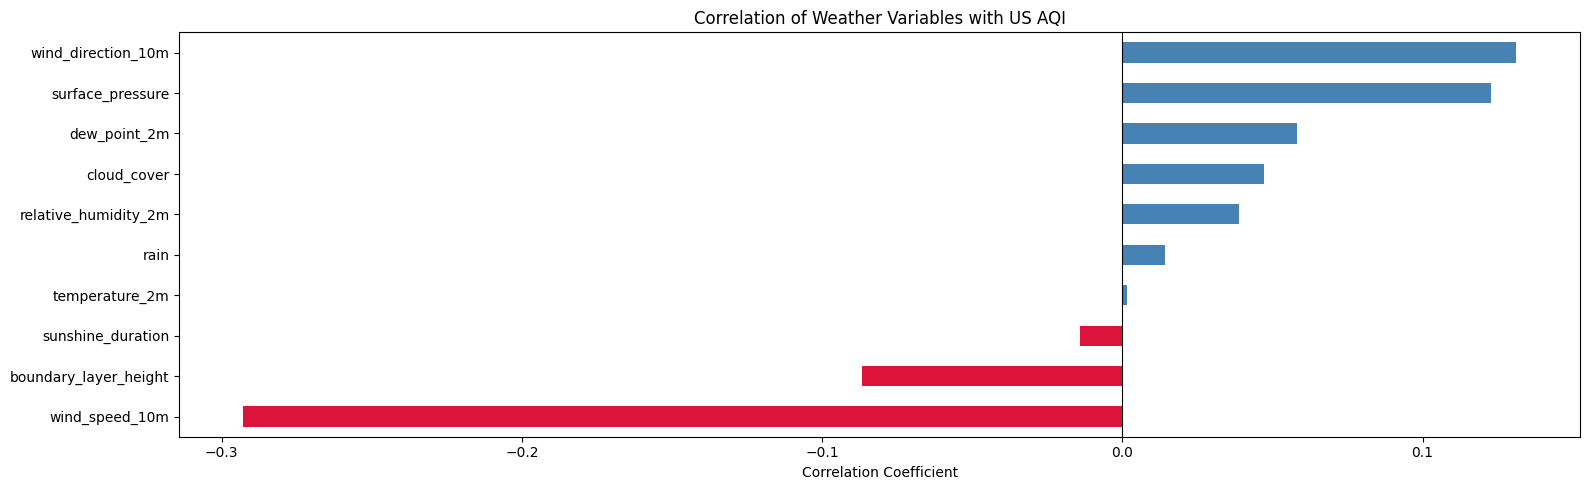

In [15]:
plt.figure(figsize=(16, 5))
corr_with_aqi.plot(
    kind="barh", color=["steelblue" if v > 0 else "crimson" for v in corr_with_aqi]
)
plt.title("Correlation of Weather Variables with US AQI")
plt.xlabel("Correlation Coefficient")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# Distribution of Weather by AQI category


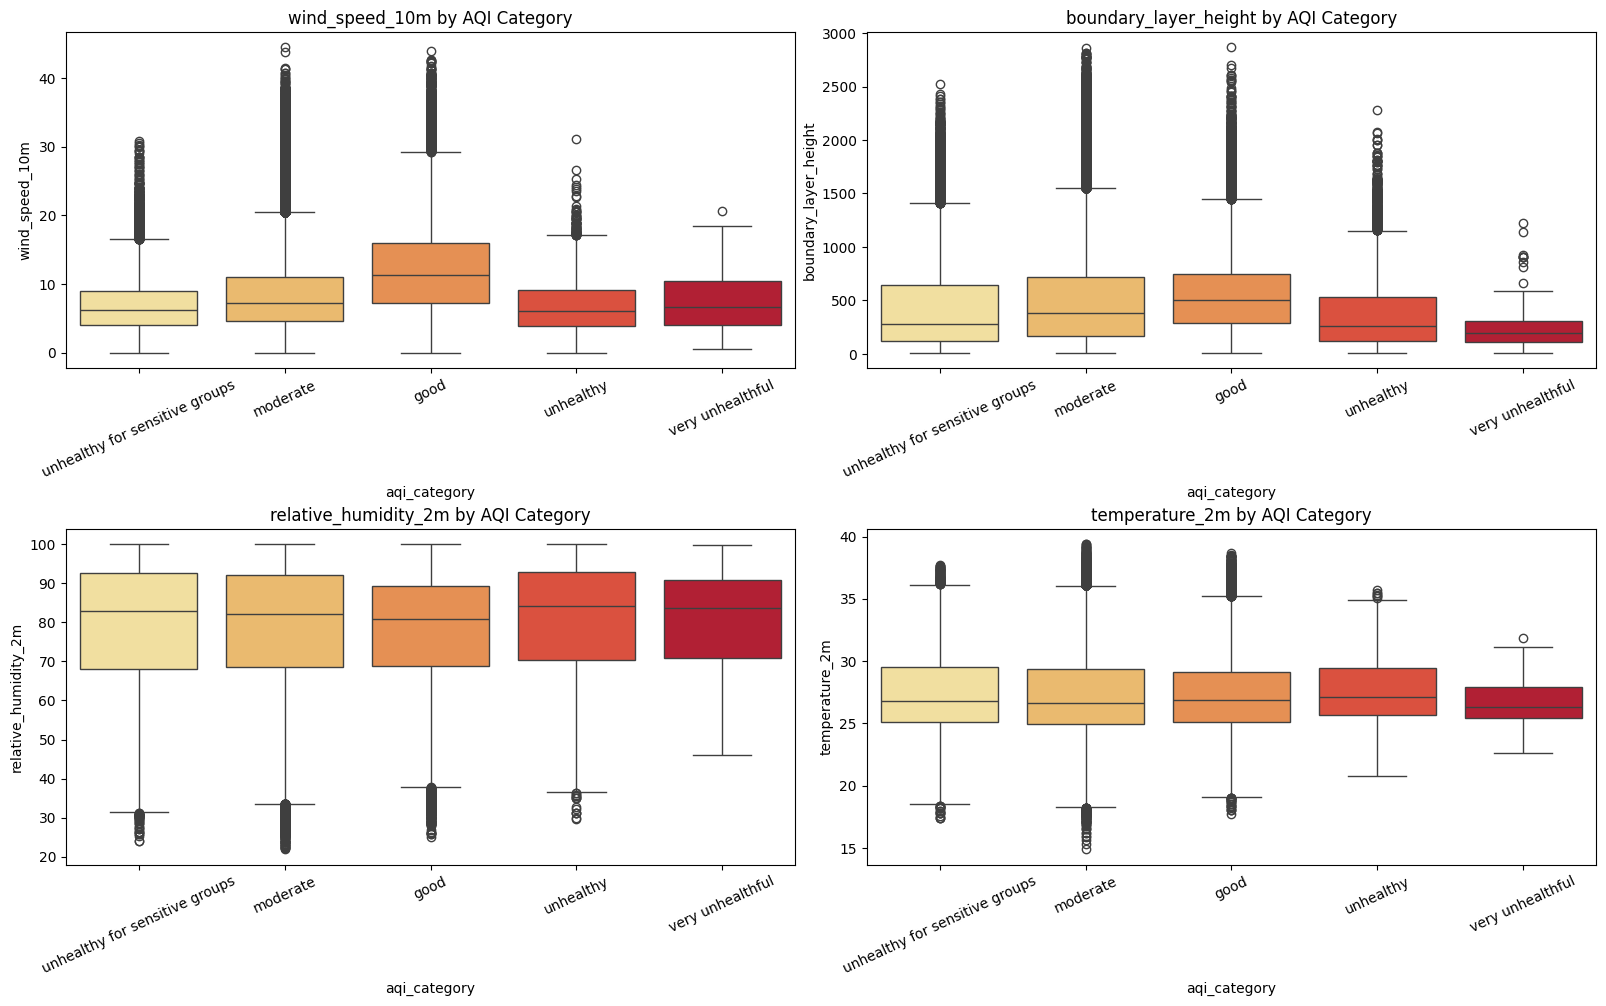

In [6]:
category_order = df["aqi_category"].unique().tolist()

key_weather_vars = [
    "wind_speed_10m",
    "boundary_layer_height",
    "relative_humidity_2m",
    "temperature_2m",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_weather_vars):
    sns.boxplot(
        data=df,
        x="aqi_category",
        y=col,
        order=category_order,
        ax=axes[i],
        palette="YlOrRd",
    )
    axes[i].set_title(f"{col} by AQI Category")
    axes[i].tick_params(axis="x", rotation=25)

plt.tight_layout(pad=0.5)
plt.show()

In [7]:
print(
    "ANOVA Test - H0: the means of the variable are the same across AQI Category groups:"
)
for col in weather_numeric_cols:
    groups = [df[df["aqi_category"] == cat][col].dropna() for cat in category_order]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) < 2:
        print(f"{col:<25} not enough groups with data to perform the test")
        continue
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "significant (p<0.05)" if p_value < 0.05 else "NOT significant"
    print(f"{col:<25} | F={f_stat:<10.2f} | p={p_value:<15.4e} | {significance:<20}")

ANOVA Test - H0: the means of the variable are the same across AQI Category groups:
temperature_2m            | F=27.02      | p=1.8707e-22      | significant (p<0.05)
relative_humidity_2m      | F=47.77      | p=3.2109e-40      | significant (p<0.05)
rain                      | F=21.75      | p=5.7680e-18      | significant (p<0.05)
surface_pressure          | F=830.39     | p=0.0000e+00      | significant (p<0.05)
cloud_cover               | F=144.42     | p=1.3843e-123     | significant (p<0.05)
wind_speed_10m            | F=7311.21    | p=0.0000e+00      | significant (p<0.05)
wind_direction_10m        | F=1109.72    | p=0.0000e+00      | significant (p<0.05)
sunshine_duration         | F=18.24      | p=5.4449e-15      | significant (p<0.05)
boundary_layer_height     | F=296.84     | p=3.3340e-255     | significant (p<0.05)
dew_point_2m              | F=228.07     | p=7.0888e-196     | significant (p<0.05)


# Analysis by time


## Aqi by hour of the day


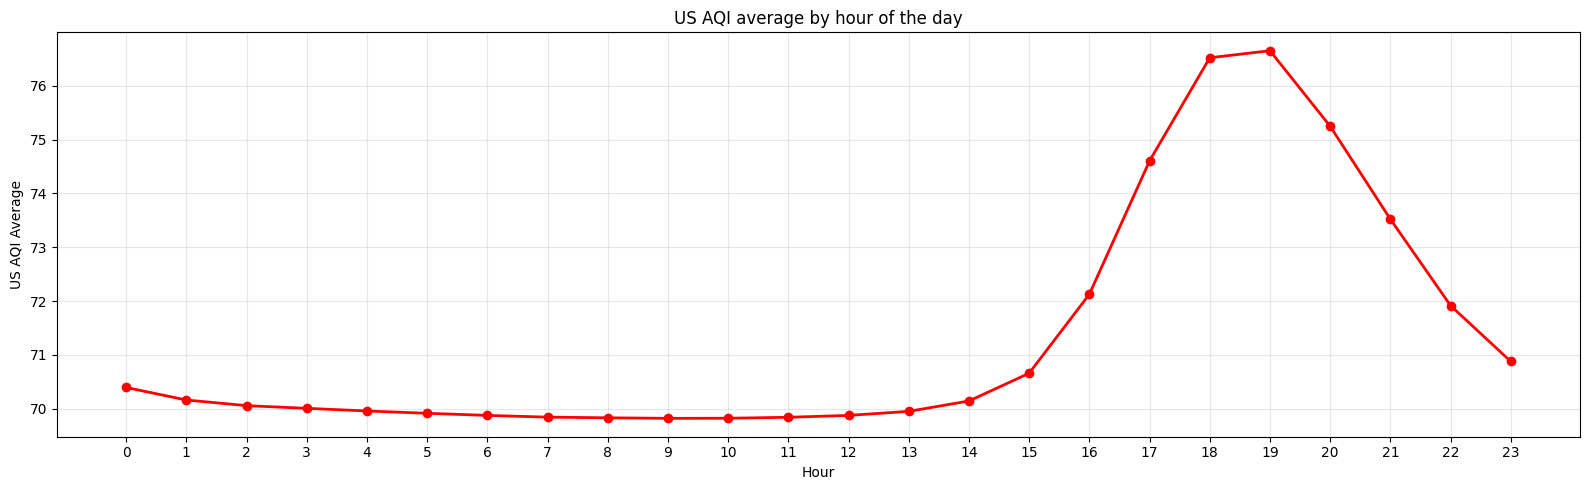

In [8]:
hourly_aqi = df.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(16, 5))
hourly_aqi.plot(marker="o", color="red", linewidth=2, markersize=6)
plt.title("US AQI average by hour of the day")
plt.xlabel("Hour")
plt.ylabel("US AQI Average")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Aqi by season


In [9]:
df.groupby("season")["us_aqi"].agg(["mean", "median", "std"])

,mean,median,std
season,,,
dry,70.165088,64.76951,25.316767
rainy,72.571115,68.12943,26.361861


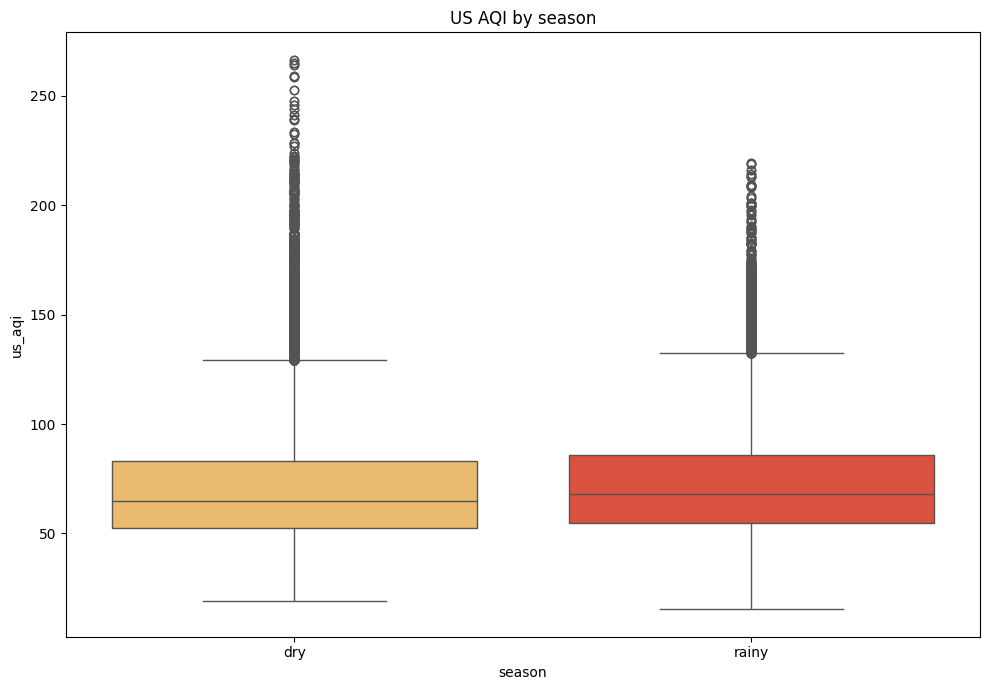

In [16]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x="season", y="us_aqi", palette="YlOrRd")
plt.title("US AQI by season")
plt.tight_layout()
plt.show()

## AQI by day of week


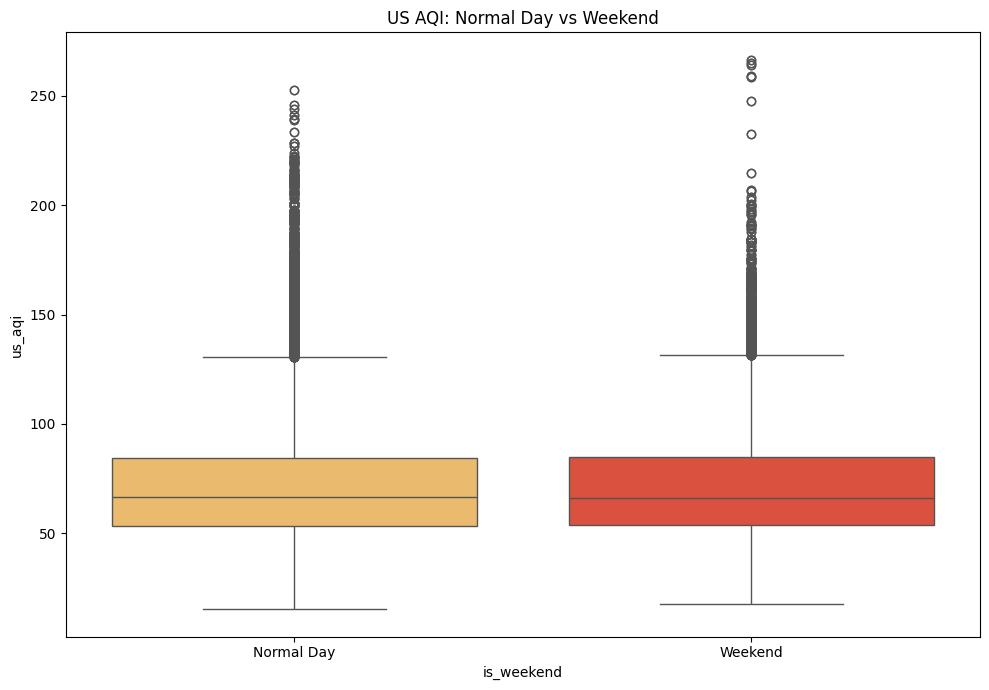

In [17]:
plt.figure(figsize=(10, 7))
sns.boxplot(data=df, x="is_weekend", y="us_aqi", palette="YlOrRd")
plt.xticks([0, 1], ["Normal Day", "Weekend"])
plt.title("US AQI: Normal Day vs Weekend")
plt.tight_layout()
plt.show()

# Analysis by location


In [12]:
df.groupby("location_name")["us_aqi"].agg(["mean", "median", "std", "max"]).sort_values(
    "mean", ascending=False
)

,mean,median,std,max
location_name,,,,
Bien Hoa,81.953459,77.570930,24.763935,212.32547
Dĩ An,81.953459,77.570930,24.763935,212.32547
Thuận An,81.953459,77.570930,24.763935,212.32547
Ho Chi Minh City,81.953459,77.570930,24.763935,212.32547
Thu Dau Mot,81.953459,77.570930,24.763935,212.32547
Tay Ninh,68.901232,64.175540,26.677732,177.45535
Long Khánh,63.825225,61.184959,19.947621,182.23853
Dong Xoai,60.259139,58.927300,18.545732,177.77423
Thanh Pho Ba Ria,55.214024,51.959220,21.147694,266.43396


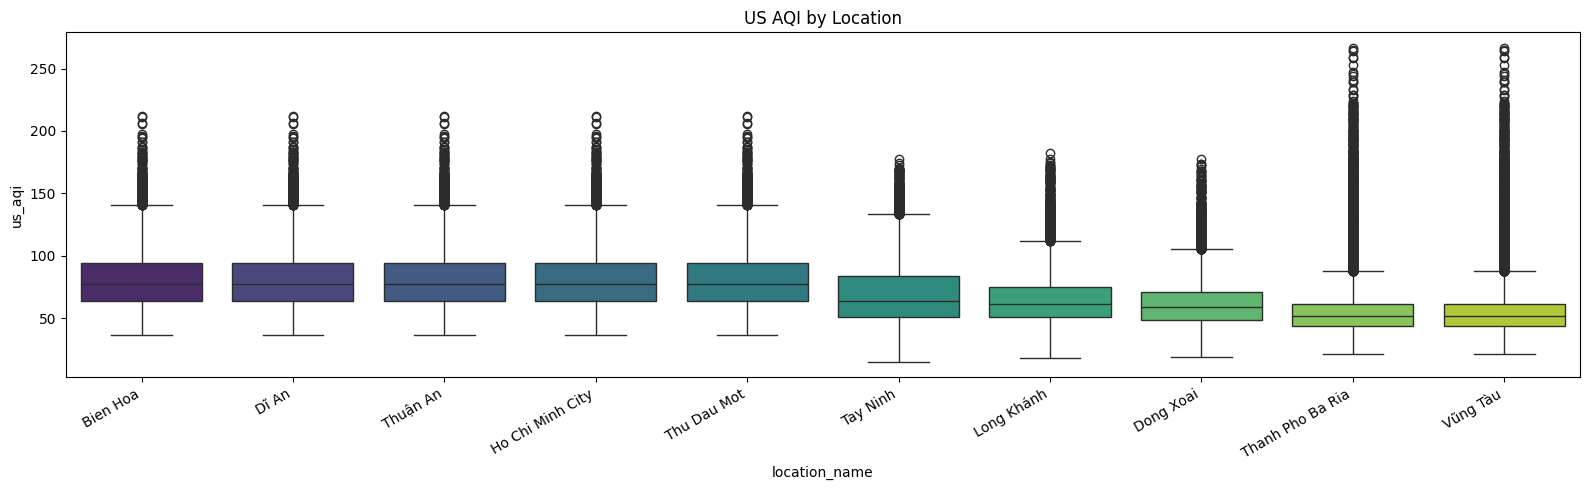

In [20]:
plt.figure(figsize=(16, 5))
order_by_median = (
    df.groupby("location_name")["us_aqi"].median().sort_values(ascending=False).index
)
sns.boxplot(
    data=df, x="location_name", y="us_aqi", order=order_by_median, palette="viridis"
)
plt.title("US AQI by Location")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Save

In [14]:
df.to_csv("../data/clean/data2.csv", index=False)